# 04 — Model Training
**Goal:** Train 4 models (SVM, Random Forest, MLP, CNN) on extracted MFCC features, compare accuracy, and save the best model.

## 1. Check Libraries

In [3]:
import importlib
importlib.invalidate_caches()
import tensorflow as tf
print(tf.__version__)

2.21.0


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print(f"numpy:        {np.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"tensorflow:   {tf.__version__}")
print("\nAll libraries ready ✅")

numpy:        2.3.5
pandas:       2.3.3
tensorflow:   2.21.0

All libraries ready ✅


## 2. Load features.csv

In [16]:
df = pd.read_csv('features.csv')
print(f"Shape: {df.shape}")
print(f"Label distribution:")
print(df['label'].value_counts().sort_index().to_string())
df.head()

Shape: (4240, 41)
Label distribution:
label
0    688
1    592
2    592
3    592
4    592
5    592
6    592


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,...,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39,label
0,-681.92530,60.253666,0.606010,13.558146,8.389651,0.470501,-3.646512,-3.577835,-12.171617,-3.223377,...,-2.347052,-2.998035,-2.032508,-3.536474,-1.709354,-1.207591,-1.952652,-3.854637,-1.693044,0
1,-674.35480,61.282314,-1.758771,17.722033,9.725379,-0.205105,-1.563526,-5.904859,-12.915890,-1.533724,...,-2.980965,-2.388265,-2.739164,-3.356074,-0.902344,-1.438924,-3.428027,-3.562944,-2.562082,0
2,-677.84033,62.683060,-0.074478,14.536501,5.596521,1.039011,-2.469042,-6.033867,-11.388467,-4.138160,...,-2.332745,-2.617405,-2.085288,-3.020938,-2.170061,-1.221695,-2.983992,-3.828454,-2.457575,0
3,-676.63980,58.588737,2.639020,13.680299,7.092484,2.882377,-1.914978,-7.563103,-11.114905,-3.638864,...,-2.318527,-3.073290,-2.957253,-3.449866,-1.575281,-1.043560,-2.619672,-3.638883,-3.580294,0
4,-695.96030,72.433810,2.809904,16.982683,8.941421,1.745872,-4.281387,-4.778624,-11.778305,-5.999314,...,-1.476523,-2.303163,-2.894165,-2.110953,-0.509307,-2.114303,-2.019947,-4.525523,-3.172242,0


## 3. Prepare Data

In [17]:
EMOTION_LABELS = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']
NUM_CLASSES    = len(EMOTION_LABELS)

# Separate features and labels
X = df.drop('label', axis=1).values   # shape: (4240, 40)
y = df['label'].values                 # shape: (4240,)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# First split — 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Second split — 70% train, 10% val (from the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
)
# 0.125 x 80% = 10% of total data

print(f"X_train shape: {X_train.shape}  → 70%")
print(f"X_val shape:   {X_val.shape}    → 10%")
print(f"X_test shape:  {X_test.shape}   → 20%")
print(f"Classes:       {NUM_CLASSES}")

# For CNN — reshape to (samples, timesteps, features)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# For CNN — one-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print("Data preparation done ✅")

X_train shape: (2968, 40)  → 70%
X_val shape:   (424, 40)    → 10%
X_test shape:  (848, 40)   → 20%
Classes:       7
Data preparation done ✅


## 4. Model 1 — SVM

In [18]:
print("Training SVM ...")
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)
svm_acc   = accuracy_score(y_test, svm_preds)

print(f"SVM Accuracy: {svm_acc * 100:.2f}%")

Training SVM ...
SVM Accuracy: 84.43%


## 5. Model 2 — Random Forest

In [19]:
print("Training Random Forest ...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)

print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")

Training Random Forest ...
Random Forest Accuracy: 84.91%


## 6. Model 3 — MLP

In [20]:
print("Training MLP ...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    max_iter=300,
    random_state=42
)
mlp_model.fit(X_train, y_train)

mlp_preds = mlp_model.predict(X_test)
mlp_acc   = accuracy_score(y_test, mlp_preds)

print(f"MLP Accuracy: {mlp_acc * 100:.2f}%")

Training MLP ...
MLP Accuracy: 89.62%


## 7. Model 4 — CNN

In [21]:
print("Building CNN ...")

cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Building CNN ...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)                    │ (None, 38, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 38, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 19, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 19, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 17, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 17, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ (None, 8, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 8, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 321,927 (1.23 MB)

 Trainable params: 321,543 (1.23 MB)

 Non-trainable params: 384 (1.50 KB)

In [22]:
print("Training CNN ...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_cnn, y_val_cat),  
    callbacks=[early_stop],
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"\nCNN Test Accuracy: {cnn_acc * 100:.2f}%")

Training CNN ...
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5694 - loss: 1.3776 - val_accuracy: 0.2854 - val_loss: 1.7936
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6917 - loss: 0.8877 - val_accuracy: 0.4387 - val_loss: 1.7785
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7227 - loss: 0.7842 - val_accuracy: 0.5613 - val_loss: 1.3718
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7537 - loss: 0.6830 - val_accuracy: 0.7311 - val_loss: 0.8521
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7594 - loss: 0.6594 - val_accuracy: 0.7712 - val_loss: 0.6899
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7817 - loss: 0.5970 - val_accuracy: 0.7972 - val_loss: 0.6098
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7948 - loss: 0.5634 - val_accuracy: 0.8208 - val_loss: 0.5725
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7985 - loss: 0.5439 -

## 8. CNN Training Curves

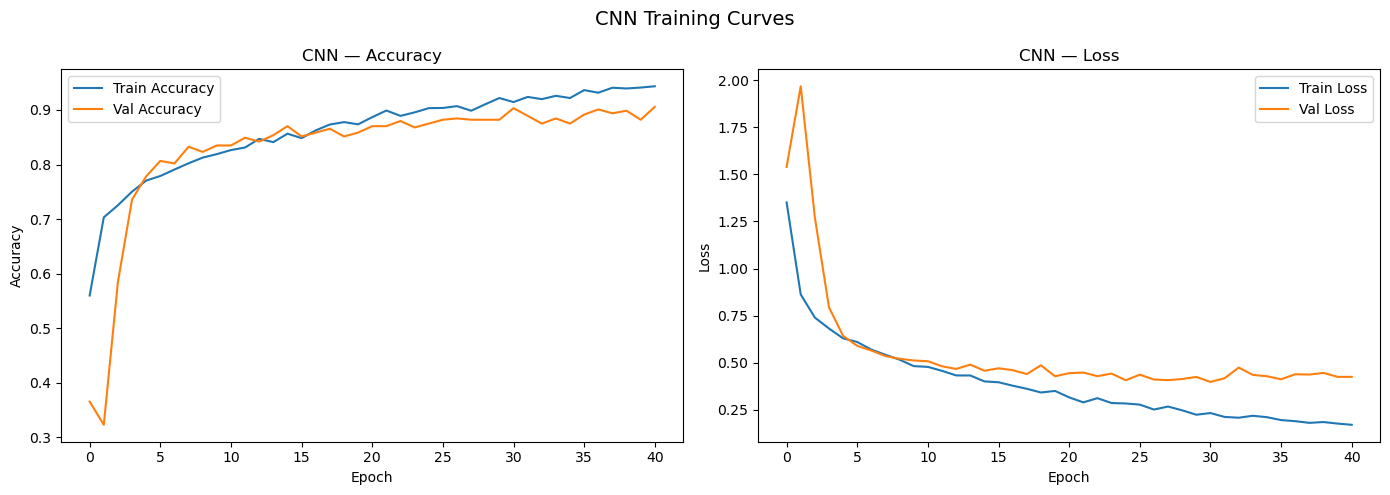

Saved: training_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('CNN — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('CNN Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## 9. Compare All Models

=== Model Comparison ===
  MLP             89.62%
  CNN             87.62%
  Random Forest   84.91%
  SVM             84.43%


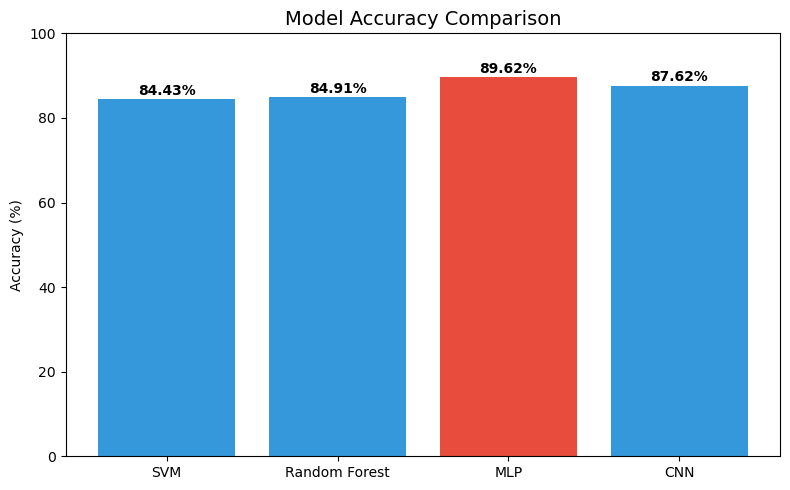

Saved: model_comparison.png


In [14]:
results = {
    'SVM':           svm_acc * 100,
    'Random Forest': rf_acc  * 100,
    'MLP':           mlp_acc * 100,
    'CNN':           cnn_acc * 100,
}

print("=== Model Comparison ===")
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model:<15} {acc:.2f}%")

# Bar chart
plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if acc == max(results.values()) else '#3498db' for acc in results.values()]
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim([0, 100])
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

## 10. Save Best Model

In [26]:
import joblib

# Save scaler — needed for live demo
joblib.dump(scaler, 'scaler.pkl')
print("Saved: scaler.pkl")

# All model results
results = {
    'SVM':           svm_acc * 100,
    'Random Forest': rf_acc  * 100,
    'MLP':           mlp_acc * 100,
    'CNN':           cnn_acc * 100,
}

# Find best model
best_model_name = max(results, key=results.get)
best_accuracy   = results[best_model_name]

print(f"\n🏆 Best model: {best_model_name} with {best_accuracy:.2f}% accuracy")

# Save the best model
if best_model_name == 'CNN':
    cnn_model.save('best_model.h5')
    print("Saved: best_model.h5 (CNN)")

elif best_model_name == 'MLP':
    joblib.dump(mlp_model, 'best_model.pkl')
    print("Saved: best_model.pkl (MLP)")

elif best_model_name == 'SVM':
    joblib.dump(svm_model, 'best_model.pkl')
    print("Saved: best_model.pkl (SVM)")

elif best_model_name == 'Random Forest':
    joblib.dump(rf_model, 'best_model.pkl')
    print("Saved: best_model.pkl (Random Forest)")

# Save best model name for later notebooks
with open('best_model_name.txt', 'w') as f:
    f.write(best_model_name)
print(f"Saved: best_model_name.txt → '{best_model_name}'")

Saved: scaler.pkl

🏆 Best model: MLP with 89.62% accuracy
Saved: best_model.pkl (MLP)
Saved: best_model_name.txt → 'MLP'


---
**Done!** All models trained and saved. Next step → `05_evaluation.ipynb`